## Prepare dataset

In [1]:
import os

DATASET_NAME = "GrenobleCTs"
DATA_PATH = "/data/galati/brain_data/GRENOBLE_CTs/Images"
complete_flag = True
#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils
def img_path_to_brain_path(img_path):
    return img_path.replace("Images", "Brains").replace(".nii.gz", "_mask.nii.gz")
# IF WE WANT TO DO EXPERIMENTS WITH COMPLETE VESSEL MASKS
def img_path_to_vessel_path(img_path):
    vessel_path = img_path.replace("Images", "Labels").replace(".nii.gz", "_vessel_filtered.nii.gz")
    return vessel_path
def img_path_to_weight_path(img_path):
    return "ERROR"

utils.img_path_to_brain_path = img_path_to_brain_path
if complete_flag:
    utils.img_path_to_weight_path = img_path_to_weight_path
    utils.img_path_to_vessel_path = img_path_to_vessel_path

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = ""

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = []

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = False
#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = True
#this parameter is to specify whether to discard slices which do not contain any portion of the brain or keep them
DISCARD_EXTRA_SLICES = True

### Extract paths

In [2]:
import os

from utils import search_nii, extract_paths, load_info_from_checkpoint

In [3]:
if not os.path.isfile(f"info_{DATASET_NAME}.pkl"):
    info = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None,
    }
    search_nii(DATA_PATH, info["train"])
else:
    print("Loading info from ", f"info_{DATASET_NAME}.pkl")
    info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

Loading info from  info_GrenobleCTs.pkl


### Display examples

In [4]:
import random

from utils import print_bold, load_and_display_middle_slice

[Example 01]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512 297   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.        0.488281  0.488281  0.625     0.        0.        0.
  0.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'Time=110957.293'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 125.0
qoffset_y       : 

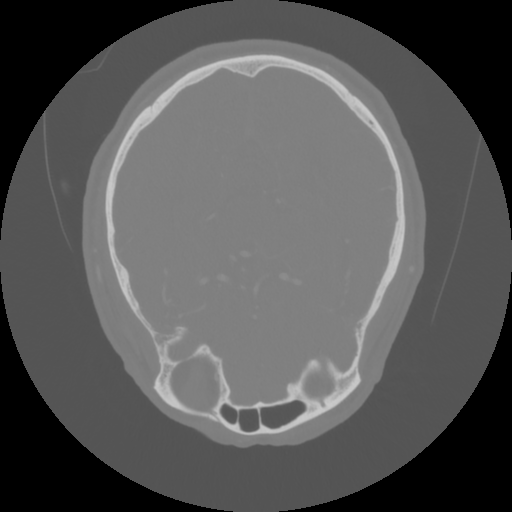

[Example 02]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512 229   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.        0.472656  0.472656  0.625     0.        0.        0.
  0.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'Time=184035.230'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 121.0
qoffset_y       : 

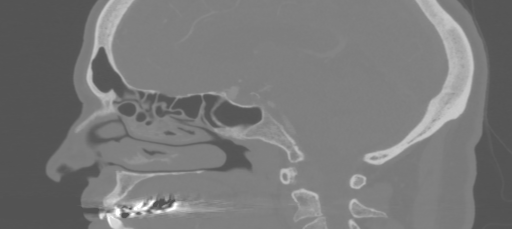

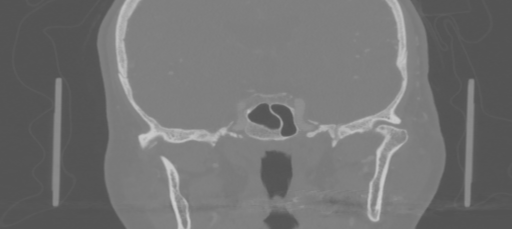

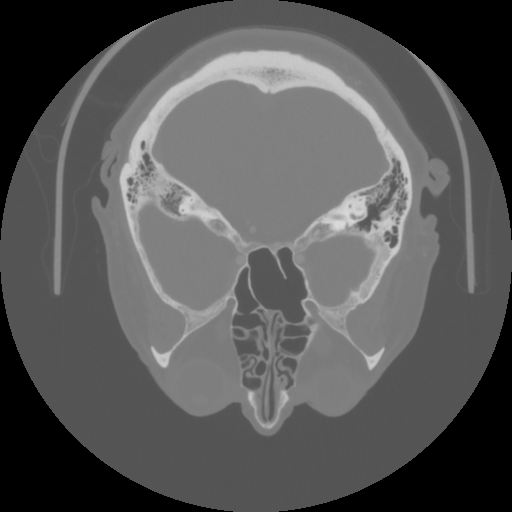

In [5]:
print_bold("[Example 01]")
random.seed(0)
load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)

print_bold("[Example 02]")
random.seed(1)
load_and_display_middle_slice(random.choice(info["train"].paths), axis=[0,1,2], display_header=True)

### Split train/val/test

In [6]:
from utils import is_medical_volume

In total, there are

In [7]:
IMGs = sum([
    info["train"].paths,
    info["val"].paths if info["val"] is not None else [],
    info["test"].paths if info["test"] is not None else []
], [])

len(IMGs)

17

volumes. First, we discard the outliers:

In [8]:
IMGs = [img_path for img_path in IMGs if os.path.basename(img_path) not in OUTLIERs]

len(IMGs)

17

We have vessel annotations for

In [9]:
PATH_VESSELs = [
    img_path_to_vessel_path(img_path) for img_path in IMGs
]

PATH_VESSELs

['/data/galati/brain_data/GRENOBLE_CTs/Labels/422810_Dataset_aini-stroke-10022_422810_Willis_Willis_20250225143802_0000_vessel_filtered.nii.gz',
 '/data/galati/brain_data/GRENOBLE_CTs/Labels/423572_Dataset_aini-stroke-12489_423572_Willis_Willis_20250225143508_0000_vessel_filtered.nii.gz',
 '/data/galati/brain_data/GRENOBLE_CTs/Labels/426135_Dataset_aini-stroke-15115_426135_Willis_Willis_20250225142004_vessel_filtered.nii.gz',
 '/data/galati/brain_data/GRENOBLE_CTs/Labels/426145_Dataset_aini-stroke-11982_426145_Willis_Willis_20250225141932_vessel_filtered.nii.gz',
 '/data/galati/brain_data/GRENOBLE_CTs/Labels/426166_Dataset_aini-stroke-18532_426166_Willis_Willis_20250225141852_vessel_filtered.nii.gz',
 '/data/galati/brain_data/GRENOBLE_CTs/Labels/426172_Dataset_aini-stroke-15013_426172_Willis_Willis_20250225141815_vessel_filtered.nii.gz',
 '/data/galati/brain_data/GRENOBLE_CTs/Labels/426186_Dataset_aini-stroke-15177_426186_Willis_Willis_20250225141648_vessel_filtered.nii.gz',
 '/data/ga

In [10]:
HAVE_VESSELs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
]



if complete_flag:
    HAVE_VESSELs = [
        img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
    ]

print("[INFO] Number of images with vessel masks: ", len(HAVE_VESSELs))
print(HAVE_VESSELs)


[INFO] Number of images with vessel masks:  2
['/data/galati/brain_data/GRENOBLE_CTs/Images/422810_Dataset_aini-stroke-10022_422810_Willis_Willis_20250225143802_0000.nii.gz', '/data/galati/brain_data/GRENOBLE_CTs/Images/423572_Dataset_aini-stroke-12489_423572_Willis_Willis_20250225143508_0000.nii.gz']


of them. With a chosen ratio of 70-15-15, we select

In [11]:
COUNT_TEST = len(HAVE_VESSELs if VESSELs_REQUIRED else IMGs) * 15 // 100
COUNT_TEST

2

images to be part of the validation/testing set.

In case brain masks are available, we collect them too.

In [12]:
HAVE_BRAINs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_brain_path(img_path))
]

len(HAVE_BRAINs)

17

The same for weight masks, delimitating the area for the calculation of losses and metrics. If available, we collect them.

In [13]:
HAVE_WEIGHTs = [
    img_path for img_path in IMGs if os.path.isfile(img_path_to_weight_path(img_path))
]

if complete_flag:
    HAVE_WEIGHTs = [
        img_path for img_path in IMGs if os.path.isfile(img_path_to_weight_path(img_path))
    ]
    
len(HAVE_WEIGHTs)

0

Finally, we randomly split our dataset. 

In [14]:
random.seed(6)
TEST_IMGs = random.sample(sorted(IMGs), COUNT_TEST)

random.seed(0)

VAL_IMGs = random.sample(sorted([img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if img not in TEST_IMGs]), COUNT_TEST)


print("val: ", [os.path.basename(img) for img in VAL_IMGs])

print("test: ", [os.path.basename(img) for img in TEST_IMGs])

TRAIN_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if img not in VAL_IMGs and img not in TEST_IMGs]
sorted([os.path.basename(img) for img in TRAIN_IMGs])

val:  ['426489_Dataset_aini-stroke-18454_426489_Willis_Willis_20250225141252.nii.gz', '426175_Dataset_aini-stroke-16590_426175_Willis_Willis_20250225141733.nii.gz']
test:  ['426130_Dataset_aini-stroke-13581_426130_Willis_Willis_20250225142037.nii.gz', '426492_Dataset_aini-stroke-13877_426492_Willis_Willis_20250225141206.nii.gz']


['422810_Dataset_aini-stroke-10022_422810_Willis_Willis_20250225143802_0000.nii.gz',
 '423572_Dataset_aini-stroke-12489_423572_Willis_Willis_20250225143508_0000.nii.gz',
 '426135_Dataset_aini-stroke-15115_426135_Willis_Willis_20250225142004.nii.gz',
 '426145_Dataset_aini-stroke-11982_426145_Willis_Willis_20250225141932.nii.gz',
 '426166_Dataset_aini-stroke-18532_426166_Willis_Willis_20250225141852.nii.gz',
 '426172_Dataset_aini-stroke-15013_426172_Willis_Willis_20250225141815.nii.gz',
 '426186_Dataset_aini-stroke-15177_426186_Willis_Willis_20250225141648.nii.gz',
 '426224_Dataset_aini-stroke-13783_426224_Willis_Willis_20250225141611.nii.gz',
 '426267_Dataset_aini-stroke-17025_426267_Willis_Willis_20250225141531.nii.gz',
 '426270_Dataset_aini-stroke-18434_426270_Willis_Willis_20250225141459.nii.gz',
 '426473_Dataset_aini-stroke-13075_426473_Willis_Willis_20250225141414.nii.gz',
 '426485_Dataset_aini-stroke-13351_426485_Willis_Willis_20250225141326.nii.gz',
 '426559_Dataset_aini-stroke-1

### Extract spacings and shapes

In [15]:
from utils import extract_info_and_masks, loop_nii, display_info, get_target_spacing

In [16]:
PERFORM_CROP = False

In [17]:
info = {
    "train": extract_info_and_masks(path_rule=PATH_RULE, perform_crop=PERFORM_CROP),
    "val": extract_info_and_masks(path_rule=PATH_RULE, perform_crop=PERFORM_CROP),
    "test": extract_info_and_masks(path_rule=PATH_RULE, perform_crop=PERFORM_CROP),
}

loop_nii(TRAIN_IMGs, info["train"])
loop_nii(VAL_IMGs, info["val"])
loop_nii(TEST_IMGs, info["test"])

Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled
Cropping disabled


In [18]:
display_info(info["train"], info["val"])

,#volumes,#slices,spacing median,spacing range,shape median,shape range
TRAIN,13,3340,[000.49 000.49 000.62],[000.42 000.42 000.62] - [000.51 000.51 000.62],[512.00 512.00 256.00],[512.00 512.00 216.00] - [512.00 512.00 297.00]
VAL,2,524,[000.49 000.49 000.62],[000.49 000.49 000.62] - [000.49 000.49 000.62],[512.00 512.00 262.00],[512.00 512.00 233.00] - [512.00 512.00 291.00]


In [19]:
SPACING = get_target_spacing(
    info["train"].spacings + info["val"].spacings,
    info["train"].shapesAfterCropping() + info["val"].shapesAfterCropping()
)

SPACING

array([0.51212286, 0.51212286, 0.625     ])

In [20]:
from utils import save_info_to_checkpoint

save_info_to_checkpoint(info, f"info_{DATASET_NAME}.pkl")

### Crop, Metadata, Resize, Empty Slices Removal, Standardization

In [21]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [22]:
import os

from utils import print_bold, preprocessing_loop

In [23]:
from pathlib import Path


OUT_DIR = "/data/falcetta/A2V_experiments/GRENOBLE_CTs_processed"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

In [24]:
print_bold("Training")
preprocessing_loop(
    info["train"],
    os.path.join(OUT_DIR,"numpy", "train"),
    target_spacing=SPACING,
    discard_extracerebral_slices=DISCARD_EXTRA_SLICES
)

print_bold("Validation")
preprocessing_loop(
    info["val"],
    os.path.join(OUT_DIR,"numpy", "val"),
    target_spacing=SPACING,
    discard_extracerebral_slices=DISCARD_EXTRA_SLICES
)

print_bold("Testing")
preprocessing_loop(
    info["test"],
    os.path.join(OUT_DIR,"numpy", "test"),
    target_spacing=SPACING,
    discard_extracerebral_slices=DISCARD_EXTRA_SLICES
)

Training


  0%|          | 0/13 [00:00<?, ?it/s]

(512, 512, 221)
Target spacing: [0.51212286 0.51212286 0.625     ]
Current spacing: [0.488281 0.488281 0.625   ]
New shape: [488 488 221]
Resized shape: (488, 488, 221)
PASSED New shape: [512, 512]
New shape: [512 512 221]
Resized shape: (512, 512, 221)
WE ARE DISCARDING EXTRACEREBRAL SLICES




  8%|▊         | 1/13 [01:08<13:47, 68.97s/it]

Slices processed: 178
(512, 512, 289)
Target spacing: [0.51212286 0.51212286 0.625     ]
Current spacing: [0.488281 0.488281 0.625   ]
New shape: [488 488 289]
Resized shape: (488, 488, 289)
PASSED New shape: [512, 512]
New shape: [512 512 289]
Resized shape: (512, 512, 289)
WE ARE DISCARDING EXTRACEREBRAL SLICES




...

(512, 512, 268)
Target spacing: [0.51212286 0.51212286 0.625     ]
Current spacing: [0.441406 0.441406 0.625   ]
New shape: [441 441 268]
Resized shape: (441, 441, 268)
PASSED New shape: [512, 512]
New shape: [512 512 268]
Resized shape: (512, 512, 268)
WE ARE DISCARDING EXTRACEREBRAL SLICES




 50%|█████     | 1/2 [01:00<01:00, 60.00s/it]

Slices processed: 182
(512, 512, 299)
Target spacing: [0.51212286 0.51212286 0.625     ]
Current spacing: [0.460938 0.460938 0.625   ]
New shape: [461 461 299]
Resized shape: (461, 461, 299)
PASSED New shape: [512, 512]
New shape: [512 512 299]
Resized shape: (512, 512, 299)
WE ARE DISCARDING EXTRACEREBRAL SLICES




100%|██████████| 2/2 [02:11<00:00, 65.95s/it]

Slices processed: 414


In [25]:
from utils import save_info_to_checkpoint

save_info_to_checkpoint(info, f"info_{DATASET_NAME}.pkl")

### Outliers removal and slices extraction

In [26]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [27]:
import os

from utils import print_bold, extraction_loop, display_slice

In [29]:
print_bold("Training")
extraction_loop(
    info["train"],
    os.path.join(OUT_DIR,"slices", "train")
)

print_bold("Validation")
extraction_loop(
    info["val"],
    os.path.join(OUT_DIR,"slices", "val")
)

print_bold("Testing")
extraction_loop(
    info["test"],
    os.path.join(OUT_DIR,"slices", "test")
)

Training


100%|██████████| 13/13 [00:07<00:00,  1.80it/s]


Validation


100%|██████████| 2/2 [00:00<00:00,  2.34it/s]


Testing


100%|██████████| 2/2 [00:02<00:00,  1.00s/it]


In [30]:
from utils import save_info_to_checkpoint

save_info_to_checkpoint(info, f"info_{DATASET_NAME}.pkl")

### Intensity values analysis

In [31]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [32]:
import numpy as np

from utils import intensity_loop, display_intensity
from utils import get_percentile, display_clipped_slice

Training


100%|██████████| 13/13 [00:24<00:00,  1.92s/it]


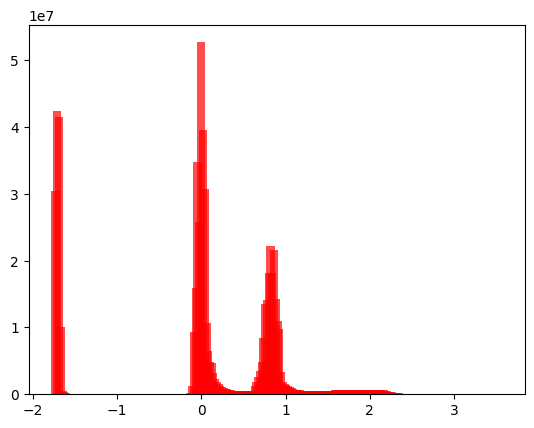

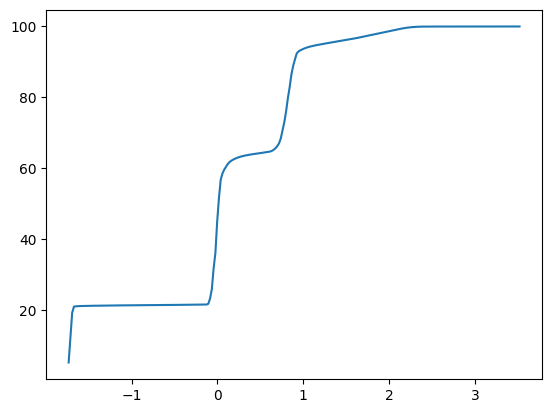

Validation


100%|██████████| 2/2 [00:04<00:00,  2.07s/it]


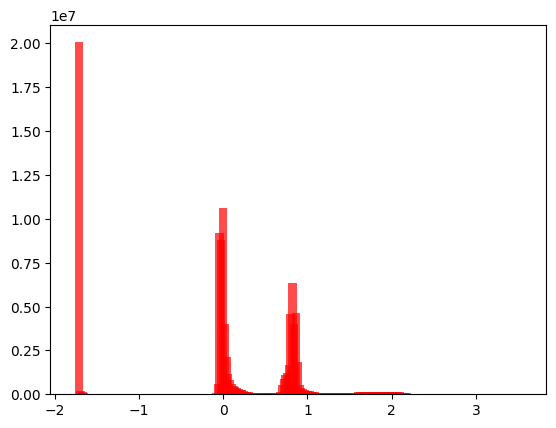

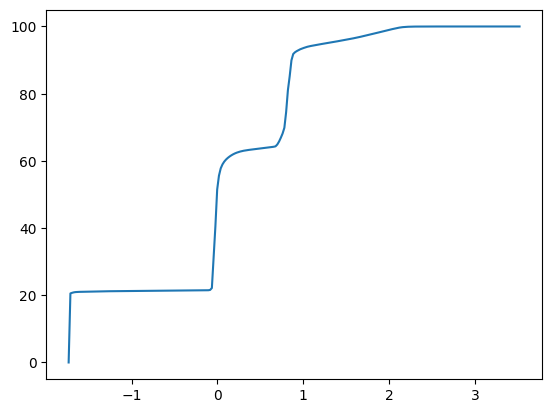

In [33]:
print_bold("Training")
intensity_loop(
    info["train"],
    min_value=min(info["train"].min_values + info["val"].min_values),
    max_value=max(info["train"].max_values + info["val"].max_values)
)
display_intensity(info["train"])

print_bold("Validation")
intensity_loop(
    info["val"],
    min_value=min(info["train"].min_values + info["val"].min_values),
    max_value=max(info["train"].max_values + info["val"].max_values)
)
display_intensity(info["val"])

In [34]:
MIN_VALUE = get_percentile(
    info["train"].bins,
    info["train"].intensity_count + info["val"].intensity_count,
    0.1
)
MAX_VALUE = get_percentile(
    info["train"].bins,
    info["train"].intensity_count + info["val"].intensity_count,
    99.9
)

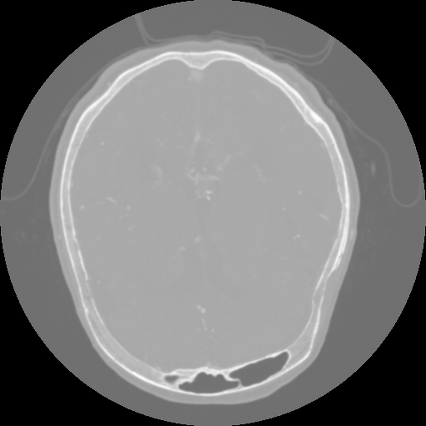

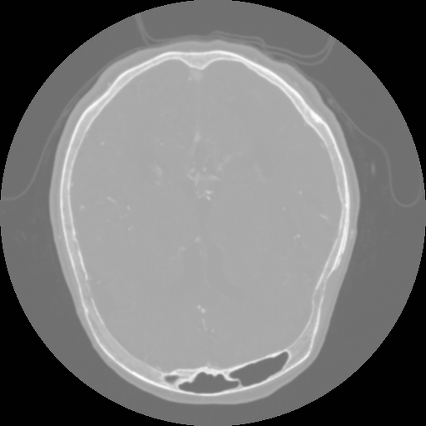

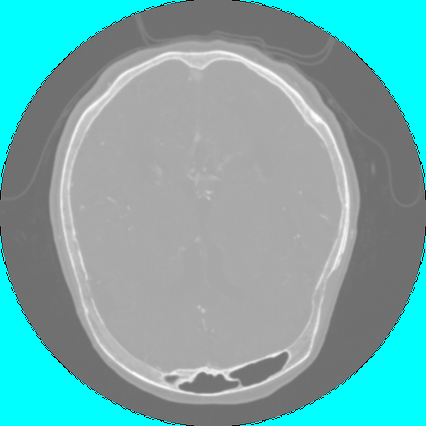

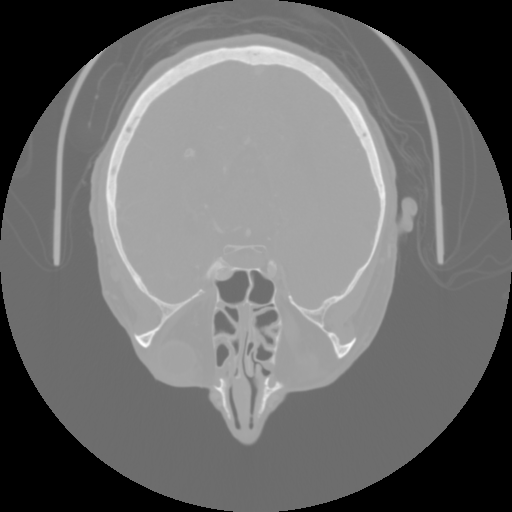

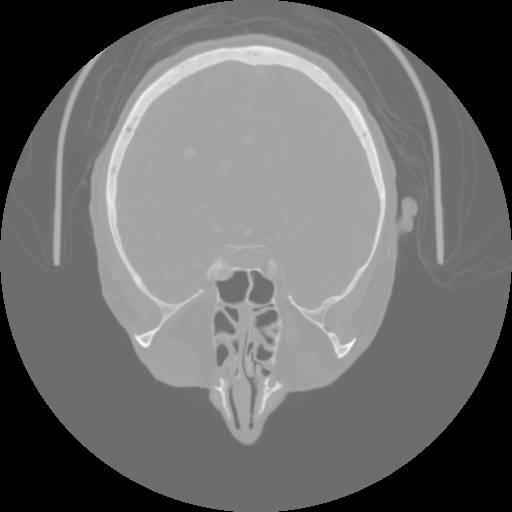

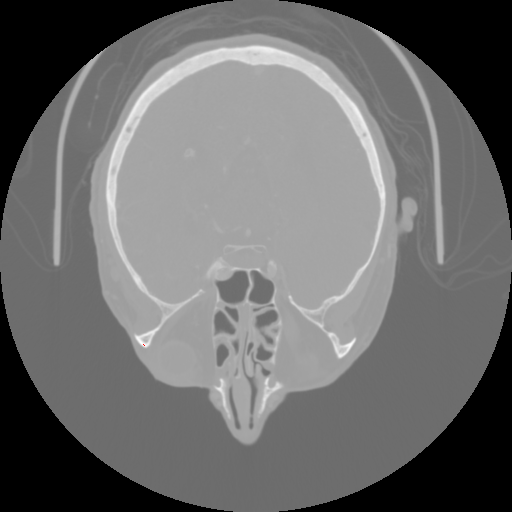

In [35]:
min_values_idx = np.argmin(
    info["train"].min_values + info["val"].min_values
)
DARK = (info["train"].preprocessed_paths + info["val"].preprocessed_paths)[min_values_idx]
DARK = DARK.replace("numpy/", "slices/").replace(".npy", "_slice{:03d}.npy").format(100)
display_clipped_slice(DARK, MIN_VALUE, MAX_VALUE)

max_values_idx = np.argmax(
    info["train"].max_values + info["val"].max_values
)
BRIGHT = (info["train"].preprocessed_paths + info["val"].preprocessed_paths)[max_values_idx]
BRIGHT = BRIGHT.replace("numpy/", "slices/").replace(".npy", "_slice{:03d}.npy").format(100)
display_clipped_slice(BRIGHT, MIN_VALUE, MAX_VALUE)

In [36]:
from utils import save_info_to_checkpoint

save_info_to_checkpoint(info, f"info_{DATASET_NAME}.pkl")

### Normalization, Padding & Cropping, One-Hot Encoding

In [37]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [38]:
import numpy as np

from utils import display_slice, normalization_loop

In [39]:
print_bold("Training")
normalization_loop(info["train"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/train", MIN_VALUE, MAX_VALUE)

print_bold("Validation")
normalization_loop(info["val"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/val", MIN_VALUE, MAX_VALUE)

print_bold("Testing")
normalization_loop(info["test"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/test", MIN_VALUE, MAX_VALUE)

Training


100%|██████████| 13/13 [00:43<00:00,  3.36s/it]


Validation


100%|██████████| 2/2 [00:06<00:00,  3.40s/it]


Testing


100%|██████████| 2/2 [00:06<00:00,  3.36s/it]


In [40]:
np.save(f"{OUT_DIR}/preprocess_map_{DATASET_NAME}.npy", {
    "train": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/train")),
    "val": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/val")),
    "test": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/test")),
})

Slice 0


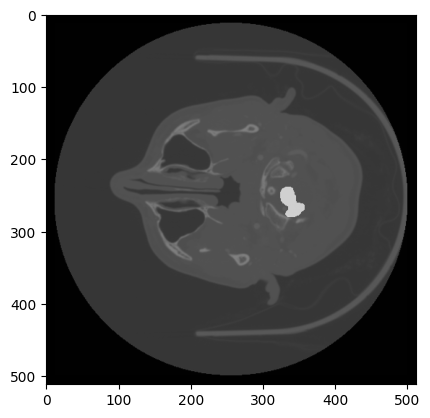

Slice 100


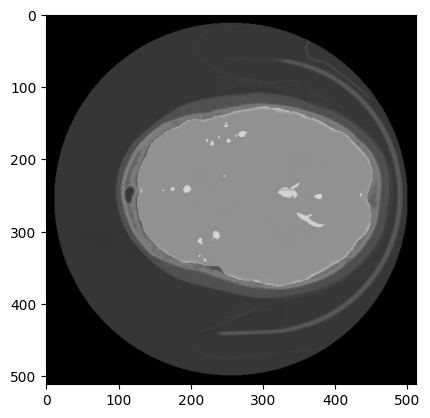

Slice 200


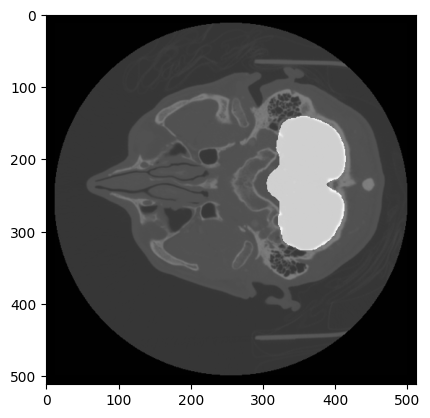

Slice 300


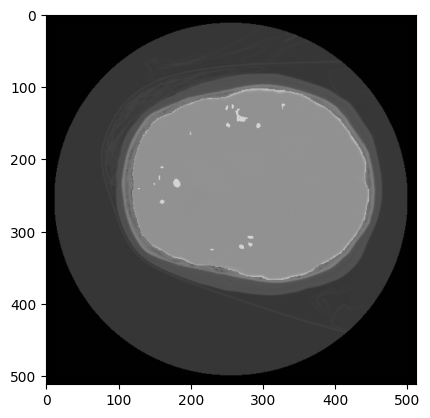

Slice 400


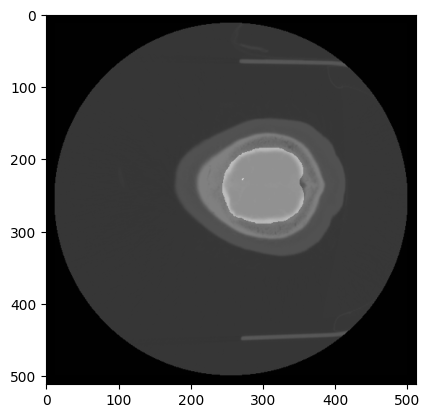

Slice 500


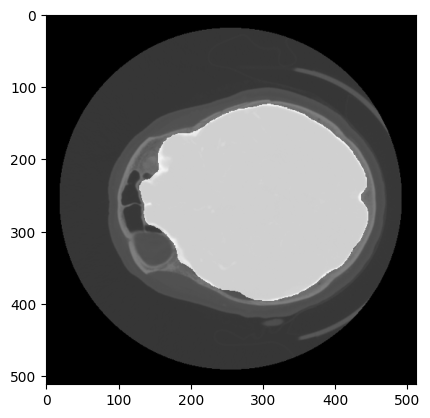

Slice 600


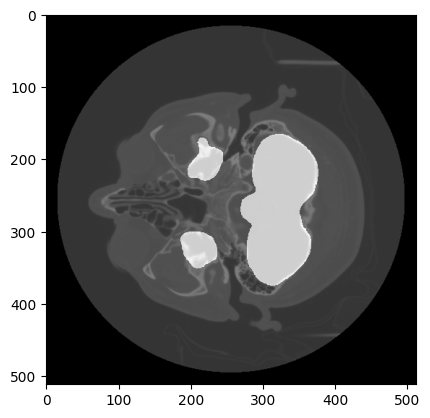

Slice 700


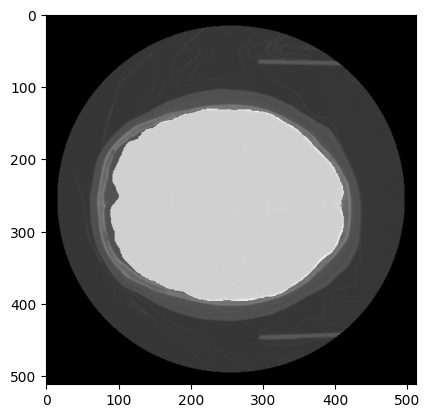

Slice 800


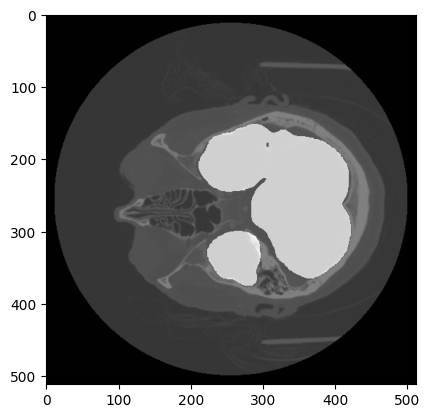

Slice 900


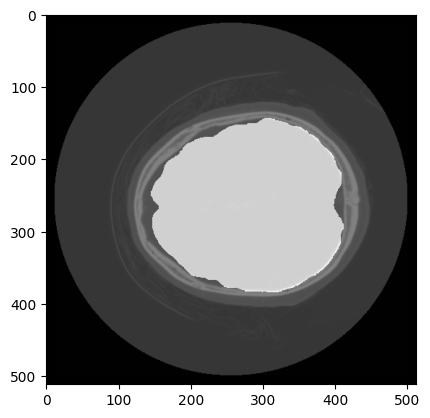

Slice 1000


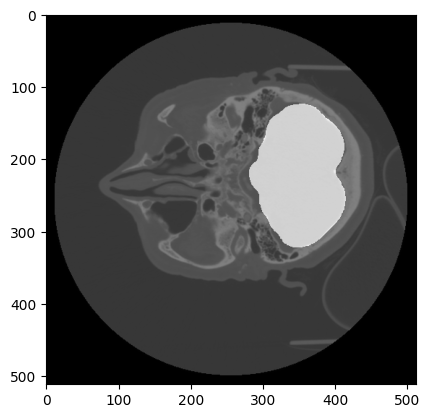

Slice 1100


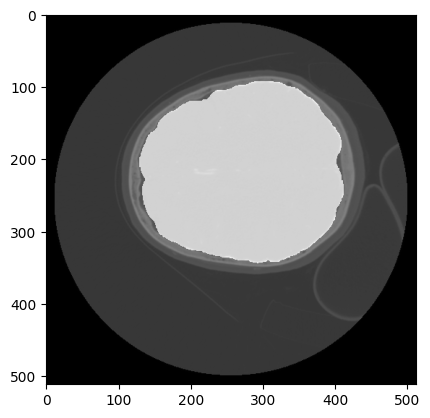

Slice 1200


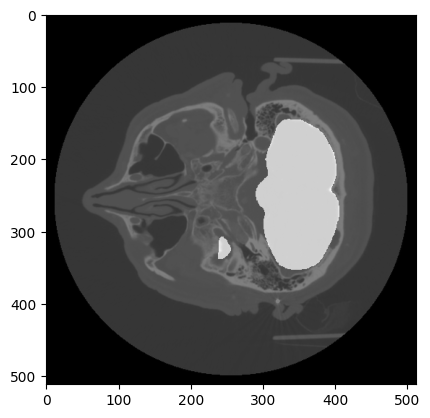

Slice 1300


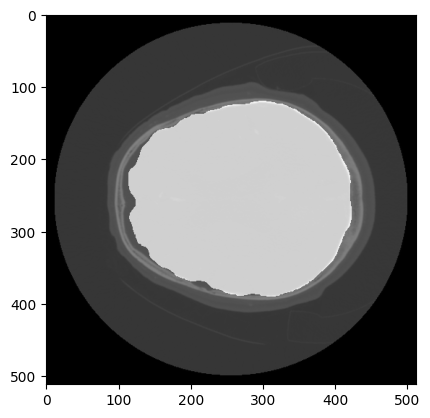

Slice 1400


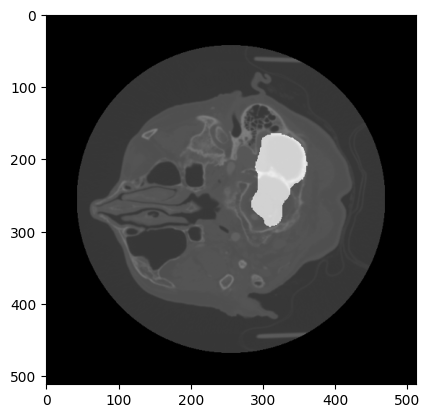

Slice 1500


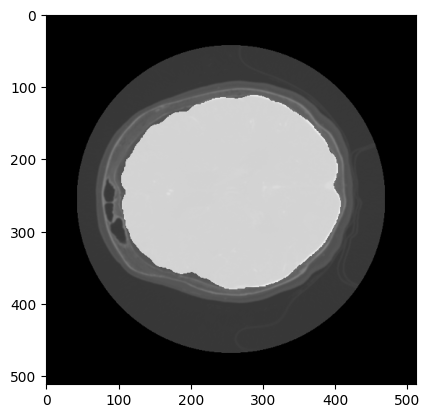

Slice 1600


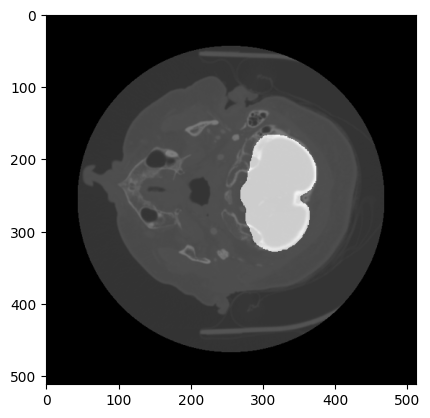

Slice 1700


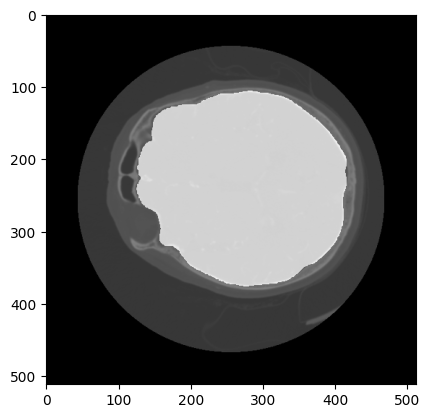

Slice 1800


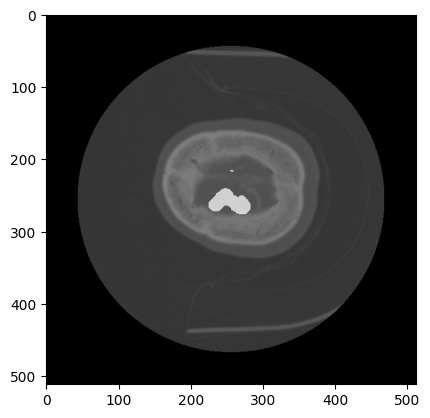

Slice 1900


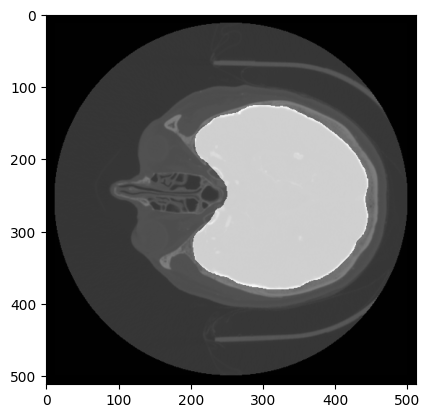

Slice 2000


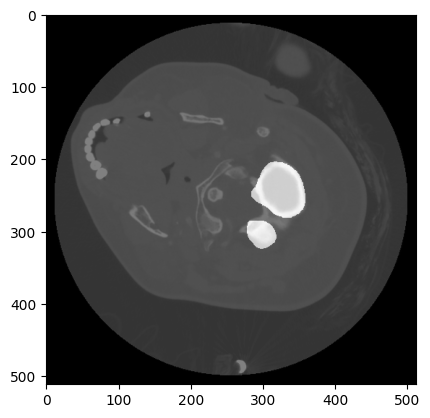

Slice 2100


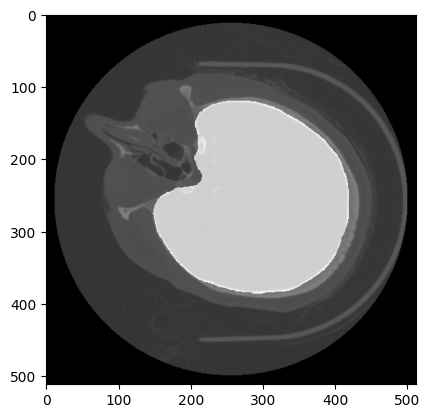

Slice 2200


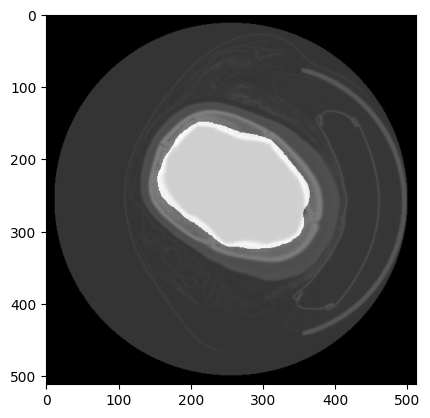

Slice 2300


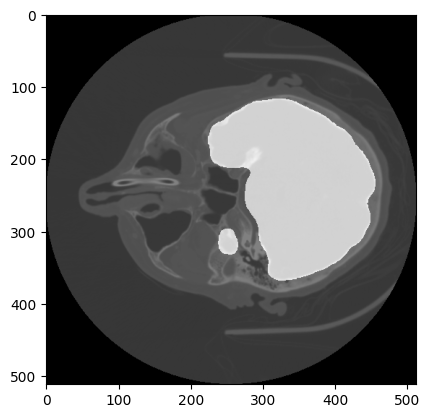

Slice 2400


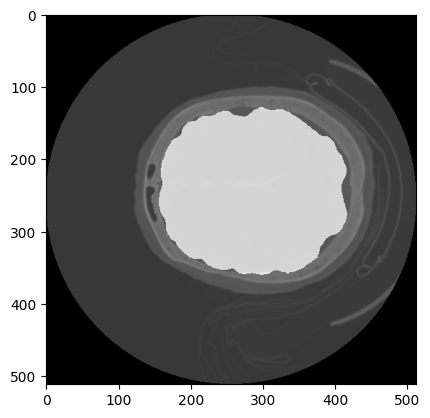

Slice 2500


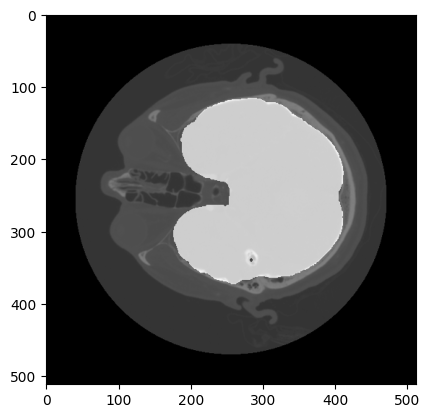

Slice 2600


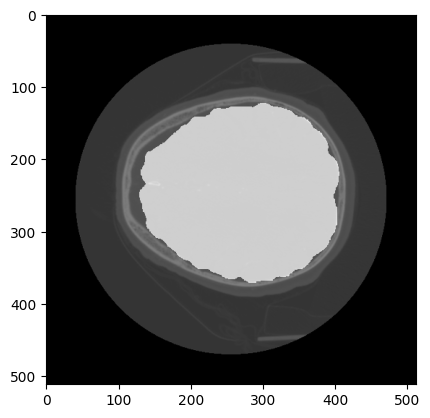

Slice 2700


IndexError: list index out of range

In [41]:
import matplotlib.pyplot as plt
from PIL import Image

for i in range(0,4000,100):
    print(f"Slice {i}")
    img_example = np.load(
        f"{OUT_DIR}/preprocess_{DATASET_NAME}/train/{sorted(os.listdir(f'{OUT_DIR}/preprocess_{DATASET_NAME}/train'))[i]}", allow_pickle=True
    ).item()

    img_example, msk_example, weight_example = img_example["data"][:,:,0], img_example["mask"], img_example["weight"]

    msk_example = np.argmax(msk_example, axis=-1)

    plt.imshow(img_example, cmap="gray")
    plt.imshow(msk_example, cmap="gray", alpha=0.5)
    plt.show()